# Mobile network traffic forecasting

**Comparative analysis of sequential models (Ridge autoregression, LSTM, causal TCN) for 10-minute Internet activity forecasting.**

This notebook contains the **complete workflow inline**, so it can be read and run as course material. It does not import `src/milan_forecast`; the code here mirrors that package line for line, so both routes give the same results. Stages:

| Section | Assignment task | Main outputs |
| --- | --- | --- |
| 1 | Setup, configuration, hardware | — |
| 2 | Memory-aware data loading (two streaming passes) | `data/processed/manifest.json`, `area_totals.csv`, `selected_areas.pkl` |
| 3 | Exploratory analysis (distribution, 5 series, ACF, daily profile) | `figures/figures/*.png`, `results/results/eda_summary.json` |
| 4 | Model design (windows, splits, scaling, metrics, 3 architectures) | — |
| 5 | Chronological tuning, final fit, test-week forecasting | `results/results/tuning.json`, `results.csv`, `metrics_area_*.csv`, `predictions_area_*.csv`, `models/models/*` |
| 6 | Results: 3 tables, 9 forecast plots, timing | `figures/figures/forecast_*.png`, `hardware.json` |
| 7 | Failure analysis | `worst_errors_area_*.csv` |
| 8 | Reload saved models and check they reproduce predictions | — |
| 9 | Tuning iteration comparison and deliverable checklist | — |

**How to run:** select the project's `.venv` kernel (Python 3.10+ with `requirements.txt` installed) and choose *Run All*. The 61 raw daily files must be in `data/raw/` (see `README.md` for download instructions). On a 6-core CPU, expect about 6 minutes for section 2 and about 20 minutes for section 5.

## 1. Setup and configuration

In [1]:
from __future__ import annotations

import json
import os
import platform
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

# Locate the repository root, whether the notebook is opened from notebooks/notebooks or the root.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "results" / "results"
FIGURES = ROOT / "figures" / "figures"
MODELS = ROOT / "models" / "models"
for directory in (PROCESSED, RESULTS, FIGURES, MODELS):
    directory.mkdir(parents=True, exist_ok=True)

# ---- Study configuration (fixed before looking at test results) ----
CHUNK_SIZE = 500_000          # rows per streamed chunk; smaller = less memory, more overhead
NAMED_AREAS = [4159, 4556]    # squares named explicitly in the assignment brief
START = pd.Timestamp("2013-11-01", tz="Europe/Rome")
END = pd.Timestamp("2014-01-01", tz="Europe/Rome")
TIMES = pd.date_range(START, END, freq="10min", inclusive="left")   # 8784 local 10-minute slots
TRAIN_END = pd.Timestamp("2013-12-09", tz="Europe/Rome")            # train targets < 9 Dec
TEST_START = pd.Timestamp("2013-12-16", tz="Europe/Rome")           # validation 9-15 Dec
TEST_END = pd.Timestamp("2013-12-23", tz="Europe/Rome")             # test 16-22 Dec
WINDOW = 144                  # previous 24 hours at 10-minute resolution
SEED = 117
MAX_EPOCHS = 40               # iteration 2; iteration 1 used 8 (see section 9)

print("Project root:", ROOT)
print("Raw files present:", len([p for p in RAW.glob("*") if p.suffix in {".txt", ".tsv", ".gz"}]))
print("Slots in study period:", len(TIMES))

Project root: D:\Milan_Traffic_Forecasting_Project\milan-traffic-forecast
Raw files present: 61
Slots in study period: 8784


## 2. Memory-aware data loading

Each daily file is a **headerless, tab-separated** table with eight columns: square ID, Unix timestamp in ms (UTC), country code, SMS in, SMS out, calls in, calls out, Internet. The whole collection is about 20.5 GB and 315 million rows, too large to load at once on a normal laptop. The strategy:

1. **Check the collection:** exactly one file per date from 1 Nov to 31 Dec 2013.
2. **Memory probe:** load the same 100,000 rows with all 8 columns, then with only the 3 we need, and compare the measured pandas memory.
3. **Pass 1 (ranking):** stream every file in chunks, reading only `square_id`, `timestamp_ms` and `internet`, and add Internet activity into a 10,001-slot array indexed by square ID.
4. **Pass 2 (extraction):** stream again, keep only the top-3 and named squares, convert UTC to Europe/Rome, and sum over country codes for each (square, 10-minute slot). Slots with no records at all are marked `NaN` (unknown), not zero.

In [2]:
NAMES = ["square_id", "timestamp_ms", "country_code", "sms_in", "sms_out", "call_in", "call_out", "internet"]
DTYPES = {"square_id": "int32", "timestamp_ms": "int64", "internet": "float64"}


def raw_files(directory: Path) -> list[Path]:
    files = sorted(p for p in directory.rglob("*") if p.is_file() and
                   (p.name.endswith(".txt") or p.name.endswith(".txt.gz") or p.name.endswith(".tsv")))
    if not files:
        raise FileNotFoundError(f"No daily .txt/.tsv/.txt.gz files in {directory}. See README.md.")
    expected = {d.strftime("%Y-%m-%d") for d in pd.date_range("2013-11-01", "2013-12-31")}
    dates = [m.group(1) for p in files if (m := re.search(r"(2013-(?:11|12)-\d{2})", p.name))]
    if len(dates) != len(files) or set(dates) != expected or len(dates) != len(set(dates)):
        missing = sorted(expected - set(dates))
        duplicates = sorted({d for d in dates if dates.count(d) > 1})
        raise ValueError(f"Expected 61 files (one per date, Nov 1 - Dec 31 2013). Found {len(files)}; "
                         f"missing={missing}; duplicate dates={duplicates}.")
    return files


def chunks(files: list[Path], chunk_size: int):
    # Only 3 of 8 columns, with compact fixed dtypes: this is the main memory optimisation.
    for file in files:
        for chunk in pd.read_csv(file, sep="\t", header=None, names=NAMES, usecols=[0, 1, 7],
                                 dtype=DTYPES, chunksize=chunk_size, compression="infer"):
            yield file.name, chunk


def current_rss_mb() -> float:
    import psutil
    return psutil.Process().memory_info().rss / (1024 * 1024)


files = raw_files(RAW)
print(f"{len(files)} daily files, {sum(f.stat().st_size for f in files) / 1e9:.2f} GB on disk")
print("First:", files[0].name, " Last:", files[-1].name)
print(pd.read_csv(files[0], sep="\t", header=None, names=NAMES, nrows=5))

61 daily files, 20.48 GB on disk
First: sms-call-internet-mi-2013-11-01.txt  Last: sms-call-internet-mi-2013-12-31.txt
   square_id   timestamp_ms  country_code    sms_in   sms_out   call_in  call_out   internet
0          1  1383260400000             0  0.081363       NaN       NaN       NaN        NaN
1          1  1383260400000            39  0.141864  0.156787  0.160938  0.052275  11.028366
2          1  1383261000000             0  0.136588       NaN       NaN  0.027300        NaN
3          1  1383261000000            33       NaN       NaN       NaN       NaN   0.026137
4          1  1383261000000            39  0.278452  0.119926  0.188777  0.133637  11.100963


In [3]:
def memory_probe(file: Path, rows: int = 100_000) -> dict:
    # Measure the same rows twice: all 8 columns (default dtypes) vs the 3 selected columns.
    full = pd.read_csv(file, sep="\t", header=None, names=NAMES, nrows=rows, compression="infer", low_memory=False)
    full_bytes = int(full.memory_usage(deep=True).sum())
    count = len(full)
    del full
    slim = pd.read_csv(file, sep="\t", header=None, names=NAMES, usecols=[0, 1, 7], dtype=DTYPES,
                       nrows=rows, compression="infer")
    slim_bytes = int(slim.memory_usage(deep=True).sum())
    return {"file": file.name, "rows": count, "full_8_column_bytes": full_bytes,
            "selected_3_column_bytes": slim_bytes,
            "reduction_percent": 100 * (1 - slim_bytes / full_bytes)}


probe = memory_probe(files[0])
print(json.dumps(probe, indent=2))
print(f"Extrapolated to 315 M rows: all columns ~{probe['full_8_column_bytes'] / probe['rows'] * 315e6 / 1e9:.1f} GB "
      f"vs selected ~{probe['selected_3_column_bytes'] / probe['rows'] * 315e6 / 1e9:.1f} GB; "
      f"streaming keeps only one {CHUNK_SIZE:,}-row chunk in memory at a time.")

{
  "file": "sms-call-internet-mi-2013-11-01.txt",
  "rows": 100000,
  "full_8_column_bytes": 6400132,
  "selected_3_column_bytes": 2000132,
  "reduction_percent": 68.748582060495
}


Extrapolated to 315 M rows: all columns ~20.2 GB vs selected ~6.3 GB; streaming keeps only one 500,000-row chunk in memory at a time.


In [4]:
def rank_areas(files: list[Path], chunk_size: int) -> tuple[pd.Series, dict]:
    # Pass 1: total Internet activity per square over the full period.
    totals = np.zeros(10001, dtype=np.float64)
    rows = 0
    for _, frame in chunks(files, chunk_size):
        if frame.square_id.isna().any() or frame.timestamp_ms.isna().any():
            raise ValueError("Missing square/time key in raw data")
        ids = frame.square_id.to_numpy()
        if ((ids < 1) | (ids > 10000)).any():
            raise ValueError("Square ID outside 1..10000")
        internet = frame.internet.fillna(0).to_numpy(dtype=np.float64)   # empty field = no Internet events
        if (internet < 0).any():
            raise ValueError("Negative Internet activity")
        np.add.at(totals, ids, internet)
        rows += len(frame)
    series = pd.Series(totals[1:], index=np.arange(1, 10001), name="total_internet")
    series = series.sort_values(ascending=False, kind="stable")          # ties: smaller ID first
    evidence = {"rows_scanned": rows, "chunk_size": chunk_size, "rss_mb_after_scan": current_rss_mb(),
                "totals_array_bytes": totals.nbytes,
                "memory_measurement_note": "RSS after scan is process-wide current memory, not isolated chunk memory or process peak; baseline is measured before scan. Full frame is measured separately by memory_probe."}
    return series, evidence


rss_before = current_rss_mb()
t0 = time.perf_counter()
ranking, scan_evidence = rank_areas(files, CHUNK_SIZE)
print(f"Pass 1: {scan_evidence['rows_scanned']:,} rows in {time.perf_counter() - t0:.0f} s; "
      f"RSS before {rss_before:.0f} MB, after {scan_evidence['rss_mb_after_scan']:.0f} MB")
top3 = [int(i) for i in ranking.index[:3]]
print("Full-period top three squares:", top3)
display(ranking.head(10).to_frame())

Pass 1: 314,966,126 rows in 186 s; RSS before 326 MB, after 41 MB
Full-period top three squares: [5161, 5059, 5259]


,total_internet
5161,1.268267e+07
5059,1.109187e+07
5259,1.043679e+07
5061,9.511351e+06
5258,8.673198e+06
5159,8.652155e+06
6064,8.606663e+06
4855,8.446619e+06
4856,8.188750e+06
5262,8.131038e+06


In [5]:
def extract_areas(files: list[Path], area_ids: list[int], chunk_size: int) -> tuple[pd.DataFrame, dict]:
    # Pass 2: sum over country codes per square and local 10-minute slot; observed slots only.
    values = np.zeros((len(TIMES), len(area_ids)), dtype=np.float64)
    seen = np.zeros_like(values, dtype=np.int32)
    lookup = {area: j for j, area in enumerate(area_ids)}
    for _, frame in chunks(files, chunk_size):
        selected = frame.loc[frame.square_id.isin(area_ids)]
        if selected.empty:
            continue
        local = pd.to_datetime(selected.timestamp_ms, unit="ms", utc=True).dt.tz_convert("Europe/Rome")
        idx = TIMES.get_indexer(local)
        cols = selected.square_id.map(lookup).to_numpy(dtype=np.int32)
        valid = idx >= 0
        if valid.any():
            np.add.at(values, (idx[valid], cols[valid]), selected.internet.fillna(0).to_numpy()[valid])
            np.add.at(seen, (idx[valid], cols[valid]), 1)
    values[seen == 0] = np.nan        # a completely absent square/slot is unknown, not zero
    output = pd.DataFrame(values, index=TIMES, columns=area_ids)
    evidence = {str(a): {"observed_intervals": int((seen[:, j] > 0).sum()),
                         "missing_intervals": int((seen[:, j] == 0).sum())} for j, a in enumerate(area_ids)}
    return output, evidence


analysis_areas = list(dict.fromkeys(top3 + NAMED_AREAS))
evaluation_areas = list(dict.fromkeys([top3[0]] + NAMED_AREAS))
assert len(evaluation_areas) == 3, "Top square coincides with a named square; choose a distinct third area"
t0 = time.perf_counter()
frame, coverage = extract_areas(files, analysis_areas, CHUNK_SIZE)
print(f"Pass 2 in {time.perf_counter() - t0:.0f} s")
display(pd.DataFrame(coverage).T)

ranking.to_csv(PROCESSED / "area_totals.csv", header=True, index_label="square_id")
frame.to_pickle(PROCESSED / "selected_areas.pkl")
manifest = {"files": [p.name for p in files], "top3": top3, "evaluation_areas": evaluation_areas,
            "analysis_areas": analysis_areas, "coverage": coverage, "scan": scan_evidence,
            "rss_before_mb": rss_before, "rss_after_mb": current_rss_mb(), "memory_probe": probe,
            "calendar_timezone": "Europe/Rome",
            "missing_interval_policy": "unknown; limited past-only fill during experiments"}
(PROCESSED / "manifest.json").write_text(json.dumps(manifest, indent=2))
print("Analysis squares:", analysis_areas, " Evaluation squares:", evaluation_areas)

Pass 2 in 179 s


,observed_intervals,missing_intervals
5161,8784,0
5059,8784,0
5259,8784,0
4159,8784,0
4556,8784,0


Analysis squares: [5161, 5059, 5259, 4159, 4556]  Evaluation squares: [5161, 4159, 4556]


## 3. Exploratory data analysis

**3.1 Distribution over all 10,000 squares.** Totals are shown on a `log(1 + x)` scale because they span several orders of magnitude.

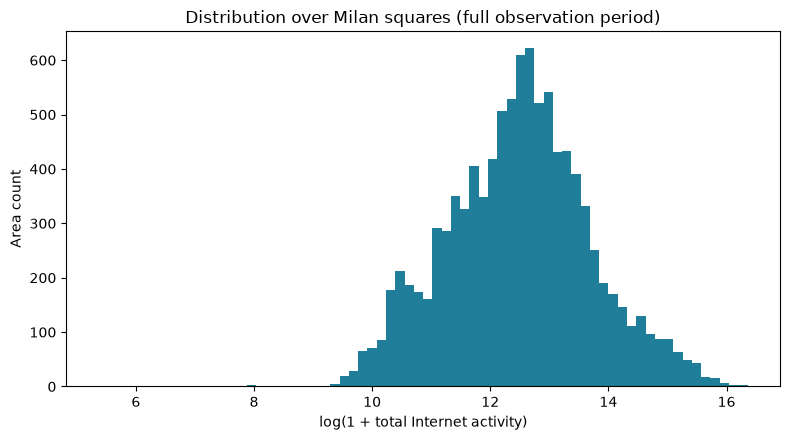

0              214
0.25       116,919
0.5        274,706
0.75       571,844
0.9      1,231,418
0.99     4,666,202
1       12,682,673
mean 549,973 | skewness 4.28 | top/median 46.2x
Rank of named squares: {4159: 423, 4556: 110}


In [6]:
def finish(path: Path):
    plt.tight_layout()
    plt.savefig(path, dpi=170, bbox_inches="tight")
    plt.show()
    plt.close()


totals = ranking
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(np.log1p(totals.values), bins=70, color="#217e9a")
ax.set(xlabel="log(1 + total Internet activity)", ylabel="Area count",
       title="Distribution over Milan squares (full observation period)")
finish(FIGURES / "area_distribution.png")

quantiles = {str(q): float(totals.quantile(q)) for q in [0, .25, .5, .75, .9, .99, 1]}
print(pd.Series(quantiles, name="total Internet activity").map("{:,.0f}".format).to_string())
print(f"mean {totals.mean():,.0f} | skewness {totals.skew():.2f} | top/median {totals.iloc[0] / totals.median():.1f}x")
print("Rank of named squares:", {a: list(totals.index).index(a) + 1 for a in NAMED_AREAS})

**3.2 First two weeks (1-14 Nov) for the three busiest squares and squares 4159 and 4556.**

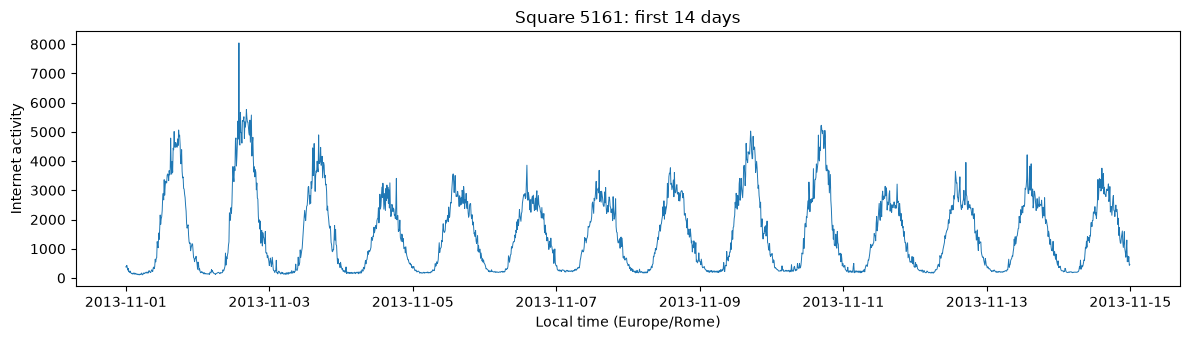

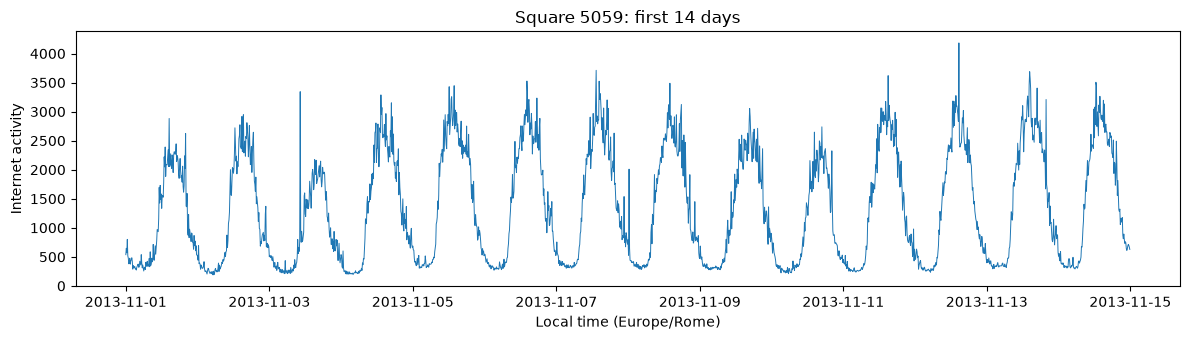

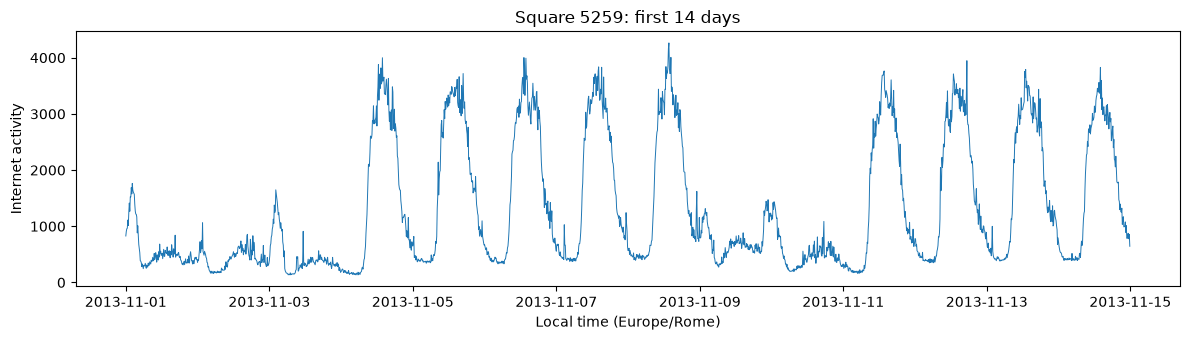

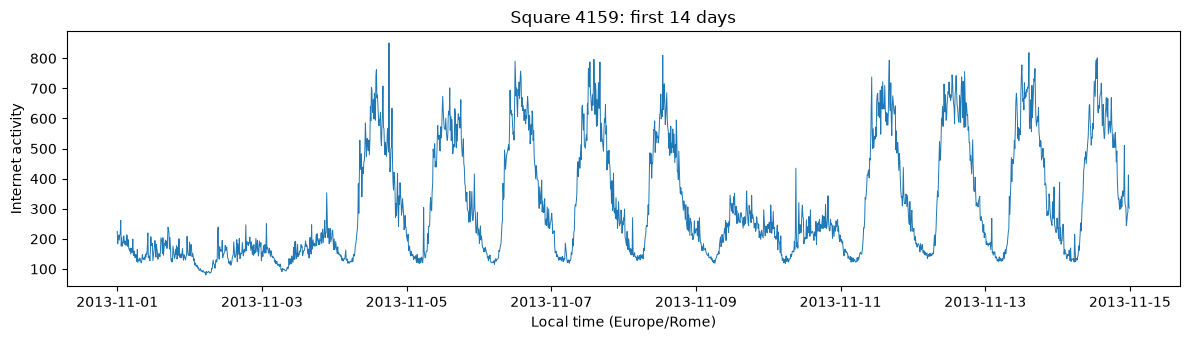

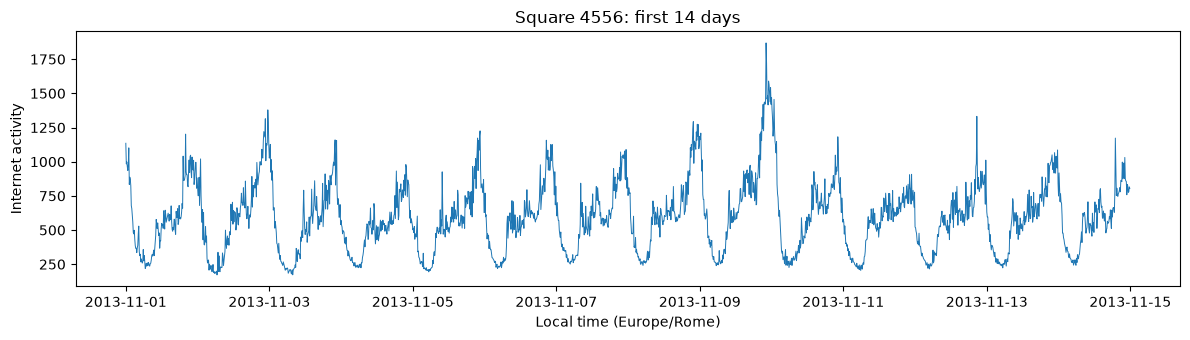

,5161,5059,5259,4159,4556
count,2016.0,2016.0,2016.0,2016.0,2016.0
mean,1483.5,1330.6,1293.5,311.3,592.7
std,1312.8,952.4,1136.7,189.3,255.6
min,104.9,189.1,134.5,80.3,172.0
25%,267.8,393.1,411.7,154.6,391.3
50%,1108.8,1078.9,707.5,234.6,582.5
75%,2457.3,2216.1,2286.3,474.2,742.2
max,8044.1,4182.8,4262.9,851.1,1868.7


In [7]:
first_two_weeks = frame.loc["2013-11-01":"2013-11-14"]
for area in analysis_areas:
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(first_two_weeks.index, first_two_weeks[area], linewidth=0.7)
    ax.set(title=f"Square {area}: first 14 days", ylabel="Internet activity", xlabel="Local time (Europe/Rome)")
    finish(FIGURES / f"first_two_weeks_area_{area}.png")
display(first_two_weeks.describe().round(1))

**3.3 Top-square analysis 1(autocorrelation).** Only data before the test week are used. Any absent slots would be forward-filled from the past only.

**3.4 Top-square analysis 2(weekday vs weekend hourly profile).**

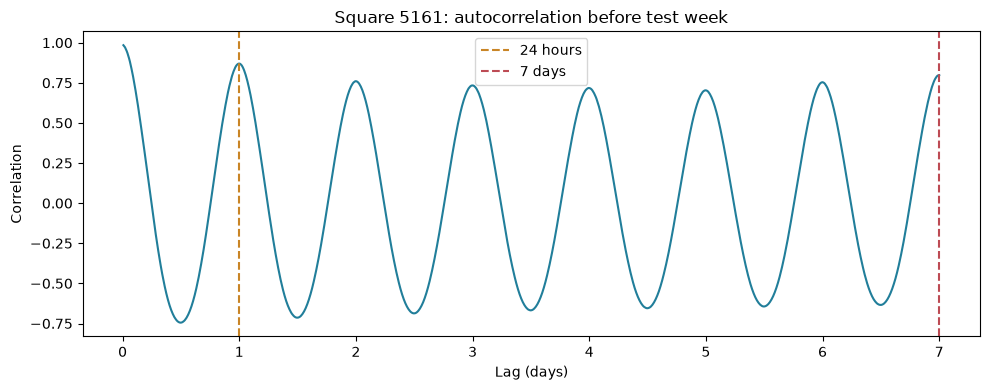

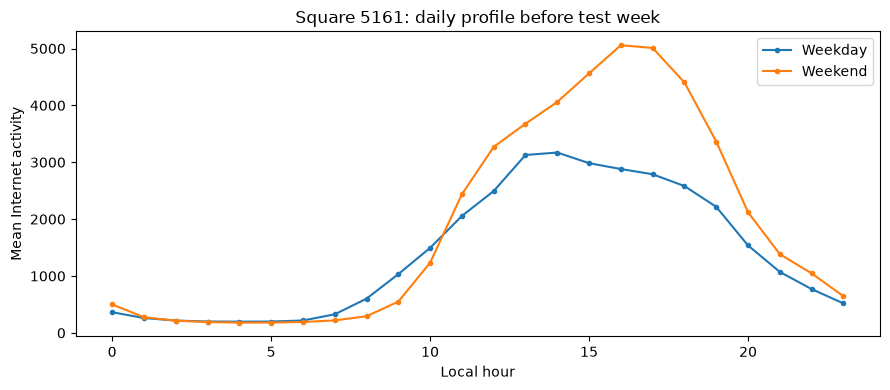

Lag correlations (1 = 10 min, 6 = 1 h, 144 = 1 day, 1008 = 1 week): {'1': 0.9843626297502489, '6': 0.9351702699907759, '144': 0.8698205183859826, '1008': 0.7978868233150411}
Peak hour weekday / weekend: 14 / 16 | peak means: 3171 / 5058


In [8]:
top = top3[0]
s = frame[top].loc[:"2013-12-15 23:59:59"].ffill().fillna(0)
z = s.to_numpy(dtype=float, copy=True)   # copy: centring must not modify s (used for the profile below)
z -= z.mean()
denom = z @ z
lags = np.arange(1, 1009)
acf = np.array([(z[:-lag] @ z[lag:]) / denom if denom else np.nan for lag in lags])
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lags / 144, acf, color="#217e9a")
ax.axvline(1, linestyle="--", color="#c98526", label="24 hours")
ax.axvline(7, linestyle="--", color="#bd4b54", label="7 days")
ax.set(xlabel="Lag (days)", ylabel="Correlation", title=f"Square {top}: autocorrelation before test week")
ax.legend()
finish(FIGURES / "top_area_acf.png")

grouped = pd.DataFrame({"activity": s.to_numpy(), "hour": s.index.hour, "weekend": s.index.dayofweek >= 5})
profile = grouped.groupby(["weekend", "hour"]).activity.mean().unstack(0)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(profile.index, profile[False], label="Weekday", marker=".")
ax.plot(profile.index, profile[True], label="Weekend", marker=".")
ax.set(xlabel="Local hour", ylabel="Mean Internet activity", title=f"Square {top}: daily profile before test week")
ax.legend()
finish(FIGURES / "top_area_daily_profile.png")

eda_stats = {"top_area": top, "top3": top3, "area_total_quantiles": quantiles,
             "lag_correlation": {str(lag): float(acf[lag - 1]) for lag in [1, 6, 144, 1008]},
             "note": "ACF and daily profile use only pre-test data; past-only filled absent intervals."}
(RESULTS / "eda_summary.json").write_text(json.dumps(eda_stats, indent=2))
print("Lag correlations (1 = 10 min, 6 = 1 h, 144 = 1 day, 1008 = 1 week):", eda_stats["lag_correlation"])
print("Peak hour weekday / weekend:", profile[False].idxmax(), "/", profile[True].idxmax(),
      "| peak means:", round(profile[False].max()), "/", round(profile[True].max()))

## 4. Model design

- **Supervised windows:** the input is the previous 144 values (24 h), and the target is the next 10-minute value. The window for target *t* covers indices *t−144 … t−1* and never contains *t*.
- **Chronological splits:** train on targets before 9 Dec, validate on 9-15 Dec (used for tuning), test on 16-22 Dec (used only once, for the final evaluation). The final models are refit on all targets before 16 Dec.
- **Missing values:** forward-filled from the past only, inside input windows. Missing targets are dropped.
- **Scaling:** `log1p`, then standardisation using statistics from the fitting targets only. Predictions are inverted with `expm1` and clipped at 0.
- **Metrics:** MAE, RMSE, and MAPE over strictly positive targets (the count of those targets is reported).

In [9]:
def series_and_validity(series: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    valid = series.notna().to_numpy()
    filled = series.ffill().fillna(0).to_numpy(dtype=np.float64)   # past-only fill
    if (filled < 0).any():
        raise ValueError("Negative Internet activity")
    return filled, valid


def split_windows(series: pd.Series, window: int = WINDOW):
    values, valid = series_and_validity(series)
    X = np.lib.stride_tricks.sliding_window_view(values, window)[:-1].copy()
    y = values[window:]
    target_times = series.index[window:]
    keep = valid[window:]
    splits = {"train": keep & (target_times < TRAIN_END),
              "val": keep & (target_times >= TRAIN_END) & (target_times < TEST_START),
              "pretest": keep & (target_times < TEST_START),
              "test": keep & (target_times >= TEST_START) & (target_times < TEST_END)}
    if not splits["train"].any() or not splits["val"].any() or not splits["test"].any():
        raise ValueError("Insufficient observed targets in a chronological split")
    return X, y, target_times, splits


class LogStandardizer:
    def fit(self, values):
        z = np.log1p(values.astype(np.float64))
        self.mean = float(np.mean(z))
        self.std = max(float(np.std(z)), 1e-8)
        return self

    def transform(self, values):
        return ((np.log1p(values) - self.mean) / self.std).astype(np.float32)

    def inverse(self, values):
        return np.maximum(np.expm1(np.asarray(values, dtype=np.float64) * self.std + self.mean), 0)


def metrics(y, pred) -> dict:
    if len(y) != len(pred) or not len(y):
        raise ValueError("Empty or unequal metric arrays")
    positive = y > 0
    return {"mae": float(mean_absolute_error(y, pred)),
            "rmse": float(np.sqrt(mean_squared_error(y, pred))),
            "mape_percent": float(np.mean(np.abs((y[positive] - pred[positive]) / y[positive])) * 100) if positive.any() else None,
            "mape_nonzero_count": int(positive.sum()), "n": int(len(y))}


# Sanity checks (the same checks as tests/test_data_and_splits.py).
_probe = pd.Series(np.arange(len(TIMES), dtype=float), index=TIMES)
_X, _y, _t, _sp = split_windows(_probe)
assert _X[0, -1] == _y[0] - 1, "window must end one step before its target (no leakage)"
assert (_t[_sp["train"]] < TRAIN_END).all() and (_t[_sp["test"]] >= TEST_START).all()
assert int(_sp["test"].sum()) == 7 * 144
_m = metrics(np.array([0., 2.]), np.array([1., 1.]))
assert _m["mae"] == 1 and _m["mape_percent"] == 50 and _m["mape_nonzero_count"] == 1
print("Leakage, split and metric checks passed; split sizes:", {k: int(v.sum()) for k, v in _sp.items()})

Leakage, split and metric checks passed; split sizes: {'train': 5328, 'val': 1008, 'pretest': 6336, 'test': 1008}


**The three model families** all get identical inputs:

1. **Ridge autoregression:** a linear model over the 144 lags with an L2 penalty. It is fast and interpretable, and serves as a strong baseline because of the high lag-1 autocorrelation.
2. **LSTM:** a gated recurrent encoder reads the sequence step by step, and a linear head maps its final hidden state to the prediction.
3. **Causal TCN:** a 1×1 input projection followed by six dilated causal convolutions (kernel 3, dilations 1, 2, …, 32), ReLU activations and a linear head on the last time step. Its receptive field is 1 + 2·(1+2+…+32) = 127 steps.

In [10]:
class LSTMForecaster(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.encoder = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.readout = nn.Linear(hidden, 1)

    def forward(self, x):
        _, (h, _) = self.encoder(x.unsqueeze(-1))
        return self.readout(h[-1]).squeeze(-1)


class CausalConv(nn.Module):
    def __init__(self, channels, dilation):
        super().__init__()
        self.pad = 2 * dilation
        self.conv = nn.Conv1d(channels, channels, 3, dilation=dilation, padding=self.pad)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv(x)[..., :-self.pad])   # drop right padding -> causal


class TCNForecaster(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.entry = nn.Conv1d(1, channels, 1)
        self.blocks = nn.Sequential(*(CausalConv(channels, 2 ** i) for i in range(6)))
        self.readout = nn.Linear(channels, 1)

    def forward(self, x):
        z = self.blocks(self.entry(x.unsqueeze(1)))
        return self.readout(z[..., -1]).squeeze(-1)


def predict_neural(model, x: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.inference_mode():
        return np.concatenate([model(torch.from_numpy(b)).numpy()
                               for b in np.array_split(x, max(1, (len(x) + 511) // 512))])


def fit_neural(kind, cfg, x, y, epochs, validation=None):
    torch.manual_seed(SEED)
    model = LSTMForecaster(cfg["width"]) if kind == "lstm" else TCNForecaster(cfg["width"])
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    criterion = nn.MSELoss()
    x_t, y_t = torch.from_numpy(x), torch.from_numpy(y)
    best_loss, best_epoch, best_state, epoch_log = float("inf"), epochs, None, []
    t0 = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        gen = torch.Generator().manual_seed(SEED + epoch)
        for indices in torch.randperm(len(x_t), generator=gen).split(256):
            opt.zero_grad(set_to_none=True)
            loss = criterion(model(x_t[indices]), y_t[indices])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        if validation is not None:
            val_loss = float(np.mean((predict_neural(model, validation[0]) - validation[1]) ** 2))
            epoch_log.append({"epoch": epoch, "validation_scaled_mse": val_loss})
            if val_loss < best_loss:
                best_loss, best_epoch = val_loss, epoch
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    fit_seconds = time.perf_counter() - t0
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_epoch, fit_seconds, epoch_log


for kind, width in [("lstm", 32), ("tcn", 32)]:
    m = LSTMForecaster(width) if kind == "lstm" else TCNForecaster(width)
    print(f"{kind.upper()} (width {width}): {sum(p.numel() for p in m.parameters()):,} parameters")
print("Ridge: 145 parameters (144 lag weights + intercept)")

LSTM (width 32): 4,513 parameters


TCN (width 32): 18,721 parameters
Ridge: 145 parameters (144 lag weights + intercept)


## 5. Chronological tuning, final fit and test-week forecasting

For each evaluation square and each model family:
1. Fit every grid candidate on the **train** split. Neural candidates record the validation MSE after every epoch and keep their best epoch.
2. Select the candidate with the **lowest validation MAE** (on the original scale).
3. Refit the selected configuration on **all pre-test targets**, for the chosen number of epochs, and time the fit.
4. Forecast the test week one step at a time; each input window contains observed history. Time the inference and save the model.

In [11]:
CONFIGS = {"ridge": [{"alpha": 0.1}, {"alpha": 10.0}],
           "lstm": [{"width": 16, "lr": 0.001}, {"width": 32, "lr": 0.001}],
           "tcn": [{"width": 16, "lr": 0.001}, {"width": 32, "lr": 0.001}]}


def run_area(series: pd.Series, area: int, max_epochs: int = MAX_EPOCHS):
    X, y, target_times, splits = split_windows(series)
    tuner = LogStandardizer().fit(y[splits["train"]])
    x_tune, y_tune = tuner.transform(X), tuner.transform(y)
    final_scaler = LogStandardizer().fit(y[splits["pretest"]])
    x_final, y_final = final_scaler.transform(X), final_scaler.transform(y)
    records, tuning = [], []
    predictions = pd.DataFrame(index=target_times[splits["test"]])
    predictions.index.name = "local_time"
    predictions["actual"] = y[splits["test"]]
    for kind, candidates in CONFIGS.items():
        scores = []
        for cfg in candidates:
            if kind == "ridge":
                candidate = Ridge(alpha=cfg["alpha"]).fit(x_tune[splits["train"]], y_tune[splits["train"]])
                pred_scaled = candidate.predict(x_tune[splits["val"]])
                best_epoch, epoch_log = None, []
            else:
                candidate, best_epoch, _, epoch_log = fit_neural(
                    kind, cfg, x_tune[splits["train"]], y_tune[splits["train"]], epochs=max_epochs,
                    validation=(x_tune[splits["val"]], y_tune[splits["val"]]))
                pred_scaled = predict_neural(candidate, x_tune[splits["val"]])
            val = metrics(y[splits["val"]], tuner.inverse(pred_scaled))
            tuning.append({"area": area, "model": kind, "config": cfg, "validation_metrics": val,
                           "selected_epoch": best_epoch, "max_epochs": max_epochs, "epoch_log": epoch_log,
                           "selection_rule": "minimum validation MAE, first candidate on tie"})
            scores.append((val["mae"], cfg, best_epoch))
            print(f"  square {area} {kind:5s} {str(cfg):28s} val MAE {val['mae']:8.2f}  best epoch {best_epoch}")
        _, chosen_cfg, chosen_epoch = min(scores, key=lambda row: row[0])
        t0 = time.perf_counter()
        if kind == "ridge":
            model = Ridge(alpha=chosen_cfg["alpha"]).fit(x_final[splits["pretest"]], y_final[splits["pretest"]])
        else:
            model, _, _, _ = fit_neural(kind, chosen_cfg, x_final[splits["pretest"]], y_final[splits["pretest"]],
                                        epochs=chosen_epoch)
        training_seconds = time.perf_counter() - t0
        identifier = f"{kind}_area_{area}"
        if kind == "ridge":
            np.savez_compressed(MODELS / f"{identifier}.npz", coef=model.coef_, intercept=model.intercept_)
        else:
            torch.save(model.state_dict(), MODELS / f"{identifier}.pt")
        (MODELS / f"{identifier}.json").write_text(json.dumps({
            "model": kind, "area": area, "configuration": chosen_cfg, "final_epochs": chosen_epoch,
            "max_epochs": max_epochs, "window_intervals": WINDOW,
            "log_scaler_mean": final_scaler.mean, "log_scaler_std": final_scaler.std,
            "note": "Only load model artifacts from sources you trust. See README for provenance."}, indent=2))
        t0 = time.perf_counter()
        scaled = model.predict(x_final[splits["test"]]) if kind == "ridge" else predict_neural(model, x_final[splits["test"]])
        prediction_seconds = time.perf_counter() - t0
        predictions[kind] = final_scaler.inverse(scaled)
        records.append({"area": area, "model": kind, **metrics(y[splits["test"]], predictions[kind].to_numpy()),
                        "chosen_config": json.dumps(chosen_cfg), "epochs_final": chosen_epoch, "max_epochs": max_epochs,
                        "final_fit_seconds": training_seconds, "week_inference_seconds": prediction_seconds,
                        "window_intervals": WINDOW, "train_targets": int(splits["train"].sum()),
                        "val_targets": int(splits["val"].sum()), "final_fit_targets": int(splits["pretest"].sum())})
    return records, predictions, tuning


all_results, all_tuning, all_predictions = [], [], {}
t_start = time.perf_counter()
for area in evaluation_areas:
    print(f"Square {area}")
    result, predictions, tuning = run_area(frame[area], area)
    all_results += result
    all_tuning += tuning
    all_predictions[area] = predictions
    predictions.to_csv(RESULTS / f"predictions_area_{area}.csv")
    pd.DataFrame(result)[["model", "mae", "mape_percent", "rmse", "mape_nonzero_count", "n"]].to_csv(
        RESULTS / f"metrics_area_{area}.csv", index=False)
results = pd.DataFrame(all_results)
results.to_csv(RESULTS / "results.csv", index=False)
(RESULTS / "tuning.json").write_text(json.dumps(all_tuning, indent=2))
hardware = {"processor": platform.processor(), "machine": platform.machine(), "platform": platform.platform(),
            "cpu_count": os.cpu_count(), "python": platform.python_version(), "pytorch": torch.__version__,
            "max_epochs": MAX_EPOCHS,
            "timing": "time.perf_counter wall clock; per-area final fit and 1008-slot week inference; excludes tuning, input loading, and plotting; CPU, one run, no uncertainty interval"}
(RESULTS / "hardware.json").write_text(json.dumps(hardware, indent=2))
print(f"Total tuning + training time: {(time.perf_counter() - t_start) / 60:.1f} min")

Square 5161
  square 5161 ridge {'alpha': 0.1}               val MAE   109.78  best epoch None
  square 5161 ridge {'alpha': 10.0}              val MAE   110.38  best epoch None


  square 5161 lstm  {'width': 16, 'lr': 0.001}   val MAE   121.49  best epoch 39


  square 5161 lstm  {'width': 32, 'lr': 0.001}   val MAE   116.45  best epoch 40


  square 5161 tcn   {'width': 16, 'lr': 0.001}   val MAE   140.72  best epoch 40


  square 5161 tcn   {'width': 32, 'lr': 0.001}   val MAE   104.06  best epoch 36


...

  square 4556 lstm  {'width': 16, 'lr': 0.001}   val MAE    35.71  best epoch 39


  square 4556 lstm  {'width': 32, 'lr': 0.001}   val MAE    35.02  best epoch 36


  square 4556 tcn   {'width': 16, 'lr': 0.001}   val MAE    34.29  best epoch 39


  square 4556 tcn   {'width': 32, 'lr': 0.001}   val MAE    33.30  best epoch 32


Total tuning + training time: 14.4 min


**Validation curves.** Each line shows one neural candidate; the dot marks the epoch that was selected. A best epoch at the cap means the model was still improving (see section 9).

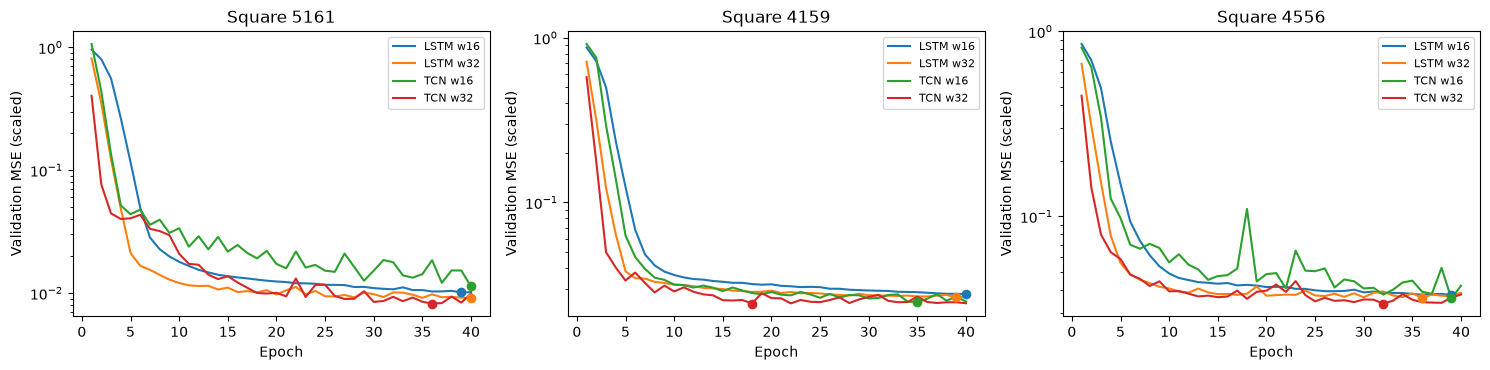

,area,model,config,val_mae,best_epoch
0,5161,ridge,"{""alpha"": 0.1}",109.78,NaN
1,5161,ridge,"{""alpha"": 10.0}",110.38,NaN
2,5161,lstm,"{""width"": 16, ""lr"": 0.001}",121.49,39.0
3,5161,lstm,"{""width"": 32, ""lr"": 0.001}",116.45,40.0
4,5161,tcn,"{""width"": 16, ""lr"": 0.001}",140.72,40.0
5,5161,tcn,"{""width"": 32, ""lr"": 0.001}",104.06,36.0
6,4159,ridge,"{""alpha"": 0.1}",22.69,NaN
7,4159,ridge,"{""alpha"": 10.0}",22.66,NaN
8,4159,lstm,"{""width"": 16, ""lr"": 0.001}",22.51,40.0
9,4159,lstm,"{""width"": 32, ""lr"": 0.001}",22.21,39.0


In [12]:
fig, axes = plt.subplots(1, len(evaluation_areas), figsize=(15, 3.8))
for ax, area in zip(axes, evaluation_areas):
    for item in (t for t in all_tuning if t["area"] == area and t["epoch_log"]):
        log = pd.DataFrame(item["epoch_log"])
        line, = ax.plot(log.epoch, log.validation_scaled_mse, label=f"{item['model'].upper()} w{item['config']['width']}")
        best = log.loc[log.epoch == item["selected_epoch"]]
        ax.scatter(best.epoch, best.validation_scaled_mse, color=line.get_color(), zorder=3)
    ax.set(title=f"Square {area}", xlabel="Epoch", ylabel="Validation MSE (scaled)", yscale="log")
    ax.legend(fontsize=8)
finish(FIGURES / "validation_curves.png")
tuning_table = pd.DataFrame([{"area": t["area"], "model": t["model"], "config": json.dumps(t["config"]),
                              "val_mae": t["validation_metrics"]["mae"], "best_epoch": t["selected_epoch"]}
                             for t in all_tuning])
display(tuning_table.round(2))

## 6. Results: three metric tables, nine forecast plots, and computation time

In [13]:
for area in evaluation_areas:
    table = results.loc[results.area == area, ["model", "mae", "mape_percent", "rmse", "chosen_config", "epochs_final"]]
    print(f"Square {area}: test week 16-22 Dec 2013 ({int(results.loc[results.area == area, 'n'].iloc[0])} slots)")
    display(table.set_index("model").round(2))

Square 5161: test week 16-22 Dec 2013 (1008 slots)


,mae,mape_percent,rmse,chosen_config,epochs_final
model,,,,,
ridge,84.42,7.70,130.48,"{""alpha"": 0.1}",NaN
lstm,90.84,7.94,144.40,"{""width"": 32, ""lr"": 0.001}",40.0
tcn,83.67,7.52,133.55,"{""width"": 32, ""lr"": 0.001}",36.0


Square 4159: test week 16-22 Dec 2013 (1008 slots)


,mae,mape_percent,rmse,chosen_config,epochs_final
model,,,,,
ridge,14.17,6.13,19.43,"{""alpha"": 10.0}",NaN
lstm,14.17,6.24,19.44,"{""width"": 32, ""lr"": 0.001}",39.0
tcn,15.35,7.13,20.29,"{""width"": 16, ""lr"": 0.001}",35.0


Square 4556: test week 16-22 Dec 2013 (1008 slots)


,mae,mape_percent,rmse,chosen_config,epochs_final
model,,,,,
ridge,25.88,5.88,35.02,"{""alpha"": 0.1}",NaN
lstm,29.45,6.92,38.53,"{""width"": 32, ""lr"": 0.001}",36.0
tcn,31.51,7.41,41.90,"{""width"": 32, ""lr"": 0.001}",32.0


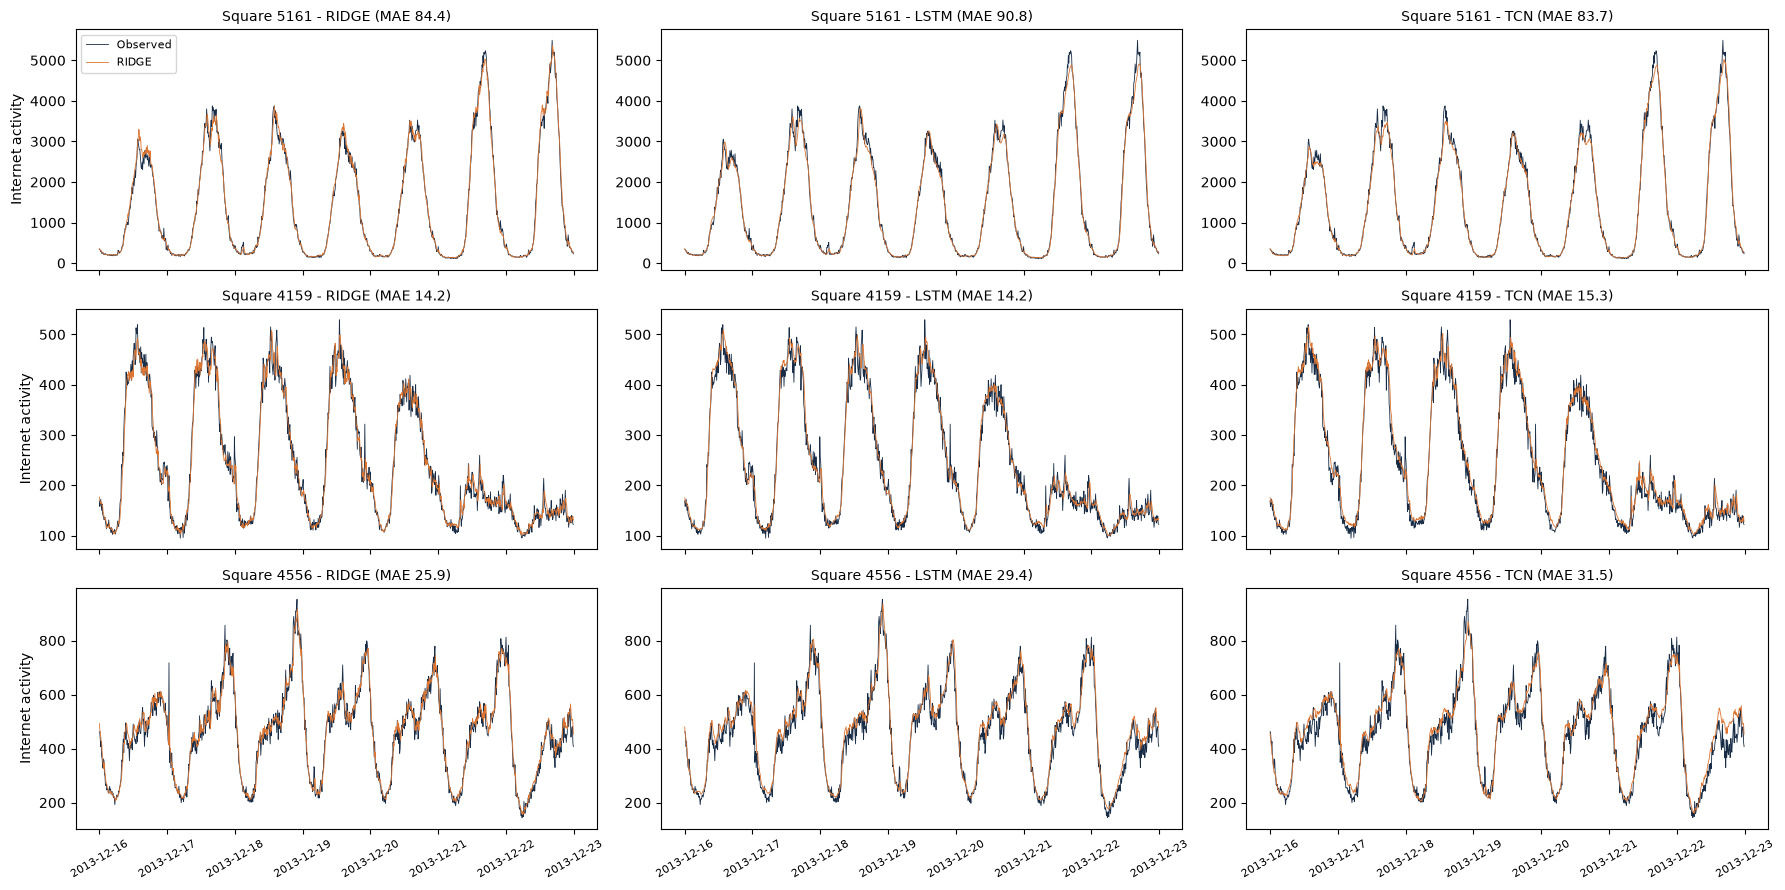

In [14]:
for area in evaluation_areas:
    prediction = all_predictions[area]
    for kind in ["ridge", "lstm", "tcn"]:
        fig, ax = plt.subplots(figsize=(12, 3.5))
        ax.plot(prediction.index, prediction.actual, linewidth=.8, label="Observed", color="#182c46")
        ax.plot(prediction.index, prediction[kind], linewidth=.8, label=kind.upper(), color="#dc7532")
        ax.set(title=f"Square {area}: {kind.upper()}, 16-22 December 2013",
               xlabel="Local time (Europe/Rome)", ylabel="Internet activity")
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIGURES / f"forecast_{kind}_area_{area}.png", dpi=170, bbox_inches="tight")
        plt.close()

# One combined 3x3 panel (rows = squares, columns = models) for the report.
fig, axes = plt.subplots(3, 3, figsize=(18, 9), sharex=True)
for i, area in enumerate(evaluation_areas):
    prediction = all_predictions[area]
    for j, kind in enumerate(["ridge", "lstm", "tcn"]):
        ax = axes[i, j]
        ax.plot(prediction.index, prediction.actual, linewidth=.6, color="#182c46", label="Observed")
        ax.plot(prediction.index, prediction[kind], linewidth=.6, color="#dc7532", label=kind.upper())
        mae = results.loc[(results.area == area) & (results.model == kind), "mae"].iloc[0]
        ax.set_title(f"Square {area} - {kind.upper()} (MAE {mae:.1f})", fontsize=10)
        ax.tick_params(axis="x", labelrotation=30, labelsize=8)
        if j == 0:
            ax.set_ylabel("Internet activity")
axes[0, 0].legend(fontsize=8)
finish(FIGURES / "forecast_panel_3x3.png")

In [15]:
timing = results.pivot(index="area", columns="model", values=["final_fit_seconds", "week_inference_seconds"])
display(timing.round(3))
print(json.dumps(hardware, indent=2))

final_fit_seconds                week_inference_seconds              
model              lstm  ridge     tcn                   lstm  ridge    tcn
area                                                                       
4159             43.447  0.007  33.301                  0.048  0.001  0.075
4556             28.720  0.012  76.422                  0.037  0.001  0.146
5161             41.073  0.008  87.480                  0.032  0.001  0.126

{
  "processor": "Intel64 Family 6 Model 158 Stepping 10, GenuineIntel",
  "machine": "AMD64",
  "platform": "Windows-11-10.0.26200-SP0",
  "cpu_count": 6,
  "python": "3.12.4",
  "pytorch": "2.14.0+cpu",
  "max_epochs": 40,
  "timing": "time.perf_counter wall clock; per-area final fit and 1008-slot week inference; excludes tuning, input loading, and plotting; CPU, one run, no uncertainty interval"
}


## 7. Failure analysis

For each model we find the test slot with the largest absolute error and show the observed and predicted values around it. We also show the daily MAE on the busiest square, to find the weakest days.

In [16]:
for area in evaluation_areas:
    predictions = all_predictions[area]
    errors = []
    for kind in ["ridge", "lstm", "tcn"]:
        worst = (predictions[kind] - predictions.actual).abs().idxmax()
        errors.append({"area": area, "model": kind, "local_time": str(worst),
                       "actual": float(predictions.loc[worst, "actual"]),
                       "predicted": float(predictions.loc[worst, kind]),
                       "absolute_error": float(abs(predictions.loc[worst, kind] - predictions.loc[worst, "actual"]))})
    errors = pd.DataFrame(errors)
    errors.to_csv(RESULTS / f"worst_errors_area_{area}.csv", index=False)
    print(f"Square {area}: largest absolute errors")
    display(errors.round(1))
    i = predictions.index.get_loc(pd.Timestamp(errors.sort_values("absolute_error").local_time.iloc[-1]))
    print("Context around the worst slot (note the one-step lag: models echo a spike one slot later):")
    display(predictions.iloc[max(0, i - 4): i + 4].round(0))

p = all_predictions[top3[0]]
daily = pd.DataFrame({k: (p[k] - p.actual).abs().groupby(p.index.date).mean() for k in ["ridge", "lstm", "tcn"]})
daily.index.name = "date"
print(f"Daily MAE on square {top3[0]}:")
display(daily.round(1))

Square 5161: largest absolute errors


,area,model,local_time,actual,predicted,absolute_error
0,5161,ridge,2013-12-17 16:00:00+01:00,3877.0,3269.8,607.1
1,5161,lstm,2013-12-22 16:20:00+01:00,5496.4,4710.0,786.4
2,5161,tcn,2013-12-17 16:00:00+01:00,3877.0,3123.5,753.5


Context around the worst slot (note the one-step lag: models echo a spike one slot later):


,actual,ridge,lstm,tcn
local_time,,,,
2013-12-22 15:40:00+01:00,4694.0,4941.0,4428.0,4621.0
2013-12-22 15:50:00+01:00,4772.0,4907.0,4497.0,4626.0
2013-12-22 16:00:00+01:00,4918.0,4977.0,4551.0,4657.0
2013-12-22 16:10:00+01:00,5202.0,5019.0,4612.0,4698.0
2013-12-22 16:20:00+01:00,5496.0,5066.0,4710.0,4840.0
2013-12-22 16:30:00+01:00,5149.0,5363.0,4847.0,4989.0
2013-12-22 16:40:00+01:00,5170.0,5244.0,4891.0,5011.0
2013-12-22 16:50:00+01:00,5198.0,5247.0,4911.0,5016.0


Square 4159: largest absolute errors


...

,area,model,local_time,actual,predicted,absolute_error
0,4556,ridge,2013-12-17 00:40:00+01:00,717.8,413.1,304.7
1,4556,lstm,2013-12-17 00:40:00+01:00,717.8,461.8,256.0
2,4556,tcn,2013-12-17 00:40:00+01:00,717.8,430.6,287.2


Context around the worst slot (note the one-step lag: models echo a spike one slot later):


,actual,ridge,lstm,tcn
local_time,,,,
2013-12-17 00:00:00+01:00,522.0,490.0,532.0,498.0
2013-12-17 00:10:00+01:00,473.0,486.0,535.0,502.0
2013-12-17 00:20:00+01:00,433.0,473.0,516.0,484.0
2013-12-17 00:30:00+01:00,415.0,435.0,487.0,459.0
2013-12-17 00:40:00+01:00,718.0,413.0,462.0,431.0
2013-12-17 00:50:00+01:00,349.0,531.0,562.0,519.0
2013-12-17 01:00:00+01:00,389.0,398.0,474.0,409.0
2013-12-17 01:10:00+01:00,388.0,401.0,443.0,418.0


Daily MAE on square 5161:


,ridge,lstm,tcn
date,,,
2013-12-16,90.2,78.9,67.4
2013-12-17,92.0,104.4,103.7
2013-12-18,89.5,106.6,95.8
2013-12-19,72.2,64.6,57.4
2013-12-20,65.6,71.7,78.8
2013-12-21,90.5,101.5,92.3
2013-12-22,91.0,108.1,90.3


## 8. Reload the saved models and check they reproduce the predictions

This shows that the files in `models/models/` are complete, usable models: weights plus the scaler and configuration in the JSON metadata.

In [17]:
def load_model(kind: str, area: int):
    meta = json.loads((MODELS / f"{kind}_area_{area}.json").read_text())
    if kind == "ridge":
        params = np.load(MODELS / f"{kind}_area_{area}.npz")
        predict = lambda x: x @ params["coef"] + params["intercept"]
    else:
        net = LSTMForecaster(meta["configuration"]["width"]) if kind == "lstm" else TCNForecaster(meta["configuration"]["width"])
        net.load_state_dict(torch.load(MODELS / f"{kind}_area_{area}.pt", weights_only=True))
        predict = lambda x: predict_neural(net, x)
    return meta, predict


checks = []
for area in evaluation_areas:
    X, y, target_times, splits = split_windows(frame[area])
    for kind in ["ridge", "lstm", "tcn"]:
        meta, predict = load_model(kind, area)
        scaler = LogStandardizer()
        scaler.mean, scaler.std = meta["log_scaler_mean"], meta["log_scaler_std"]
        reloaded = scaler.inverse(predict(scaler.transform(X[splits["test"]])))
        diff = float(np.max(np.abs(reloaded - all_predictions[area][kind].to_numpy())))
        checks.append({"area": area, "model": kind, "max_abs_difference": diff,
                       "reloaded_mae": metrics(y[splits["test"]], reloaded)["mae"]})
checks = pd.DataFrame(checks)
display(checks)
assert (checks.max_abs_difference < 1e-3).all(), "reloaded models do not reproduce the predictions"
print("All 9 saved models reload and reproduce their test-week forecasts.")

,area,model,max_abs_difference,reloaded_mae
0,5161,ridge,0.0,84.417612
1,5161,lstm,0.0,90.837199
2,5161,tcn,0.0,83.667262
3,4159,ridge,0.0,14.166202
4,4159,lstm,0.0,14.170697
5,4159,tcn,0.0,15.348584
6,4556,ridge,0.0,25.876575
7,4556,lstm,0.0,29.447080
8,4556,tcn,0.0,31.511151


All 9 saved models reload and reproduce their test-week forecasts.


## 9. Tuning iterations and deliverable checklist

**Iteration 1** capped neural training at 8 epochs. Most candidates had their best validation epoch at the cap, so they were undertrained. **Iteration 2** (this notebook, `MAX_EPOCHS = 40`) changed only that cap. The outputs of iteration 1 are archived in `results/iteration1_max8_epochs/` (regenerate them with `python run.py train --max-epochs 8`).

In [18]:
archive = ROOT / "results" / "iteration1_max8_epochs" / "results" / "results.csv"
if archive.exists():
    it1 = pd.read_csv(archive)[["area", "model", "mae", "rmse", "mape_percent", "epochs_final"]]
    comparison = it1.merge(results[["area", "model", "mae", "rmse", "mape_percent", "epochs_final"]],
                           on=["area", "model"], suffixes=("_iter1", "_iter2"))
    comparison["mae_change_percent"] = 100 * (comparison.mae_iter2 / comparison.mae_iter1 - 1)
    display(comparison.round(2))
else:
    print("Iteration 1 archive not found; run `python run.py train --max-epochs 8` and copy results to compare.")

,area,model,mae_iter1,rmse_iter1,mape_percent_iter1,epochs_final_iter1,mae_iter2,rmse_iter2,mape_percent_iter2,epochs_final_iter2,mae_change_percent
0,5161,ridge,84.42,130.48,7.70,NaN,84.42,130.48,7.70,NaN,0.00
1,5161,lstm,125.74,205.59,10.02,8.0,90.84,144.40,7.94,40.0,-27.76
2,5161,tcn,214.96,324.30,18.99,8.0,83.67,133.55,7.52,36.0,-61.08
3,4159,ridge,14.17,19.43,6.13,NaN,14.17,19.43,6.13,NaN,-0.00
4,4159,lstm,15.96,21.88,7.00,8.0,14.17,19.44,6.24,39.0,-11.21
5,4159,tcn,18.33,23.12,8.95,8.0,15.35,20.29,7.13,35.0,-16.24
6,4556,ridge,25.88,35.02,5.88,NaN,25.88,35.02,5.88,NaN,0.00
7,4556,lstm,30.28,39.87,7.01,8.0,29.45,38.53,6.92,36.0,-2.75
8,4556,tcn,37.79,48.41,8.93,8.0,31.51,41.90,7.41,32.0,-16.62


In [19]:
expected = ([PROCESSED / n for n in ["manifest.json", "area_totals.csv", "selected_areas.pkl"]]
            + [FIGURES / "area_distribution.png", FIGURES / "top_area_acf.png", FIGURES / "top_area_daily_profile.png",
               FIGURES / "forecast_panel_3x3.png", FIGURES / "validation_curves.png"]
            + [FIGURES / f"first_two_weeks_area_{a}.png" for a in analysis_areas]
            + [FIGURES / f"forecast_{k}_area_{a}.png" for a in evaluation_areas for k in ["ridge", "lstm", "tcn"]]
            + [RESULTS / n for n in ["eda_summary.json", "tuning.json", "results.csv", "hardware.json"]]
            + [RESULTS / f"{p}_area_{a}.csv" for a in evaluation_areas for p in ["metrics", "predictions", "worst_errors"]]
            + [MODELS / f"{k}_area_{a}.{e}" for a in evaluation_areas for k, e in
               [("ridge", "npz"), ("lstm", "pt"), ("tcn", "pt")]]
            + [MODELS / f"{k}_area_{a}.json" for a in evaluation_areas for k in ["ridge", "lstm", "tcn"]])
missing = [str(p.relative_to(ROOT)) for p in expected if not p.exists()]
print(f"{len(expected) - len(missing)}/{len(expected)} expected deliverable files present")
assert not missing, missing
best = results.loc[results.groupby("area").mae.idxmin(), ["area", "model", "mae", "mape_percent", "rmse"]]
print("Best model per square (by MAE):")
display(best.round(2).set_index("area"))

53/53 expected deliverable files present
Best model per square (by MAE):


,model,mae,mape_percent,rmse
area,,,,
4159,ridge,14.17,6.13,19.43
4556,ridge,25.88,5.88,35.02
5161,tcn,83.67,7.52,133.55
